# Week 2 — Understanding Dataset Format

Goal: download a small object dataset from Roboflow and understand its structure — images, labels, YAML config. Understanding data format is half the battle in any CV role.

In [1]:
!pip install roboflow ultralytics -q
!pip install python-dotenv


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\faisa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\faisa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 1 — Download a dataset from Roboflow

Go to https://universe.roboflow.com and pick any small-object dataset.
Good options to search: **drones**, **aerial cars**, **coins**, **birds**.

Click the dataset → Versions → Export → YOLOv8 format → Show download code.
Paste your download code in the cell below.

In [ ]:
# Paste YOUR Roboflow download code here — example structure:
# from roboflow import Roboflow
# rf = Roboflow(api_key="YOUR_KEY")
# project = rf.workspace("workspace").project("project-name")
# dataset = project.version(1).download("yolov8")

# !pip install roboflow

from roboflow import Roboflow
from dotenv import load_dotenv
import os
load_dotenv()
rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
project = rf.workspace("sandr").project("drone-aerial")
version = project.version(1)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to drone-aerial-1 in yolov8:: 100%|██████████| 9654/9654 [00:21<00:00, 450.92it/s]


## Step 2 — Explore the folder structure

In [5]:
import os

# Point this at the downloaded dataset folder
dataset_path = "./drone-aerial-1"  # update this

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show files 2 levels deep
        subindent = ' ' * 2 * (level + 1)
        for f in files[:5]:
            print(f'{subindent}{f}')

drone-aerial-1/
  data.yaml
  README.dataset.txt
  README.roboflow.txt
  test/
    images/
    labels/
  train/
    images/
    labels/
  valid/
    images/
    labels/


## Step 3 — Read the YAML config

The YAML file tells YOLOv8 where to find train/val/test images and what the class names are.

In [6]:
import yaml

yaml_path = "./drone-aerial-1/data.yaml"  # update this

with open(yaml_path) as f:
    config = yaml.safe_load(f)

print("Classes:", config['names'])
print("Number of classes:", config['nc'])
print("Train path:", config.get('train'))
print("Val path:", config.get('val'))

Classes: ['person']
Number of classes: 1
Train path: ../train/images
Val path: ../valid/images


## Step 4 — Read a label file

YOLOv8 labels are `.txt` files — one line per object: `class_id cx cy width height` (all normalized 0–1).

In [7]:
import glob

label_files = glob.glob(f"{dataset_path}/train/labels/*.txt")
print(f"Total training label files: {len(label_files)}")

# Read the first label file
with open(label_files[0]) as f:
    lines = f.readlines()

print(f"\nSample label file ({os.path.basename(label_files[0])})")
for line in lines:
    parts = line.strip().split()
    cls, cx, cy, w, h = parts
    print(f"  class={cls}, center=({cx},{cy}), size=({w}x{h})")

Total training label files: 4218

Sample label file (gss1006_jpg.rf.6f2c613603fe7d84c7a2f2596cf74915.txt)
  class=0, center=(0.040625,0.521875), size=(0.02734375x0.06953125)


## Step 5 — Visualize an image with its boxes

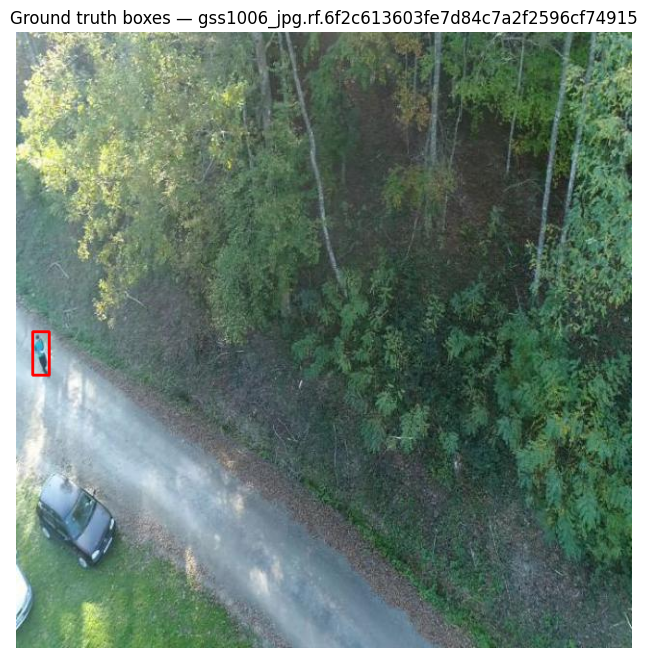

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Find the image matching the first label file
label_name = os.path.basename(label_files[0]).replace('.txt', '')
img_candidates = glob.glob(f"{dataset_path}/train/images/{label_name}.*")
img_path = img_candidates[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

with open(label_files[0]) as f:
    for line in f:
        cls, cx, cy, bw, bh = map(float, line.strip().split())
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f"Ground truth boxes — {label_name}")
plt.axis('off')
plt.show()

## What to notice

- Boxes with very **small width/height** values (e.g., 0.02 × 0.02) are the tiny objects
- Notice how small they look relative to the full image — that's why the model struggles
- The YAML is all YOLOv8 needs to train — point `model.train(data=yaml_path)` at it in Week 3